
# Thực hành Reinforcement Learning với FrozenLake

Trong buổi thực hành này, chúng ta sẽ:
- Làm quen với môi trường FrozenLake trong Gymnasium.
- Hiện thực Q-learning bằng Q-table.
- Hiện thực Q-learning với Stochastic Gradient (Q-network).
- So sánh kết quả và thảo luận.


In [1]:

!pip install gymnasium pygame torch numpy matplotlib -q


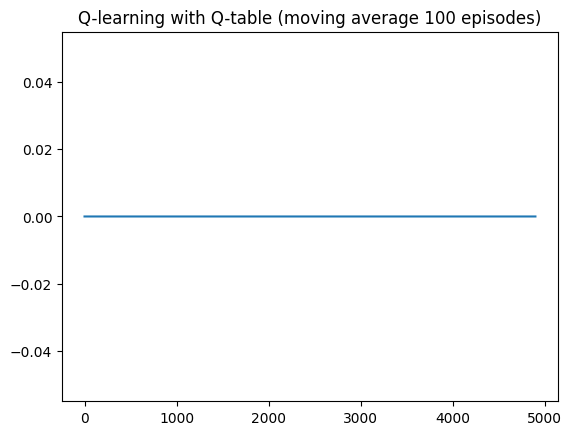

In [4]:

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

# Tạo môi trường FrozenLake
env = gym.make("FrozenLake-v1", is_slippery=False)
n_states = env.observation_space.n
n_actions = env.action_space.n

# Khởi tạo Q-table
Q = np.zeros((n_states, n_actions))

# Tham số
alpha = 0.1
gamma = 0.99
epsilon = 0.1
n_episodes = 5000

rewards = []

for episode in range(n_episodes):
    state, _ = env.reset()
    done = False
    total_reward = 0

    while not done:
        # Chọn action theo epsilon-greedy
        if np.random.rand() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(Q[state])

        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # Cập nhật Q-table
        Q[state, action] = Q[state, action] + alpha * (
            reward + gamma * np.max(Q[next_state]) - Q[state, action]
        )

        state = next_state
        total_reward += reward

    rewards.append(total_reward)

# Vẽ kết quả
plt.plot(np.convolve(rewards, np.ones(100)/100, mode="valid"))
plt.title("Q-learning with Q-table (moving average 100 episodes)")
plt.show()


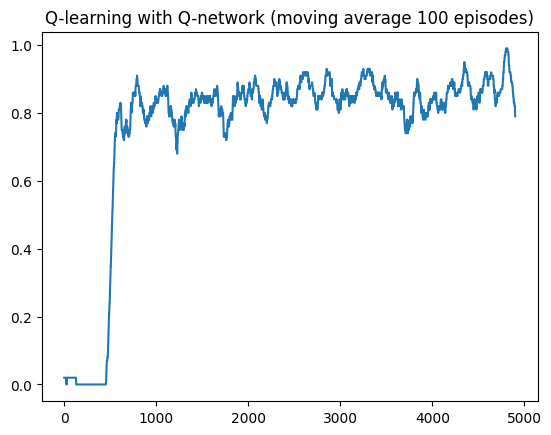

In [5]:

import torch
import torch.nn as nn
import torch.optim as optim

# One-hot encode trạng thái
def one_hot(state, n_states):
    x = np.zeros(n_states)
    x[state] = 1.0
    return torch.FloatTensor(x).unsqueeze(0)

# Mạng Q-network
class QNetwork(nn.Module):
    def __init__(self, n_states, n_actions):
        super(QNetwork, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(n_states, 32),
            nn.ReLU(),
            nn.Linear(32, n_actions)
        )
    def forward(self, x):
        return self.fc(x)

q_net = QNetwork(n_states, n_actions)
optimizer = optim.Adam(q_net.parameters(), lr=0.01)
loss_fn = nn.MSELoss()

n_episodes = 5000
gamma = 0.99
epsilon = 0.1
rewards_nn = []

for episode in range(n_episodes):
    state, _ = env.reset()
    done = False
    total_reward = 0

    while not done:
        # Epsilon-greedy
        if np.random.rand() < epsilon:
            action = env.action_space.sample()
        else:
            with torch.no_grad():
                action = torch.argmax(q_net(one_hot(state, n_states))).item()

        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # Target
        with torch.no_grad():
            target = reward + gamma * torch.max(q_net(one_hot(next_state, n_states)))

        # Q hiện tại
        q_value = q_net(one_hot(state, n_states))[0, action]

        # Tính loss và update SGD
        loss = loss_fn(q_value, target)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        state = next_state
        total_reward += reward

    rewards_nn.append(total_reward)

# Vẽ kết quả
plt.plot(np.convolve(rewards_nn, np.ones(100)/100, mode="valid"))
plt.title("Q-learning with Q-network (moving average 100 episodes)")
plt.show()


In [ ]:

plt.plot(np.convolve(rewards, np.ones(100)/100, mode="valid"), label="Q-table")
plt.plot(np.convolve(rewards_nn, np.ones(100)/100, mode="valid"), label="Q-network (SGD)")
plt.legend()
plt.title("So sánh Q-learning: Q-table vs Q-network")
plt.show()



# Bài tập mở rộng
1. Thay đổi tham số alpha, gamma, epsilon để xem ảnh hưởng.




2. So sánh kết quả khi `is_slippery=True`.


3. Tăng độ phức tạp mạng Q-network.

4. Áp dụng kỹ thuật epsilon decay thay vì epsilon cố định.

5. Ghi nhận số bước trung bình để tới goal.